In [1]:
import Augmentation_Script as augment
from AugmentationSoftwareFunctions import *
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanAbsoluteError
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import os as os

2024-07-25 20:32:13.002443: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-25 20:32:13.004347: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-07-25 20:32:13.009271: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-07-25 20:32:13.022291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-25 20:32:13.047257: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

In [2]:
dir = "/mnt/md0/tempFolder/Allen/TrainTestData/"

In [3]:

X_train = np.load(dir + 'Xtrain' + '.npy')
y_train = np.load(dir + "ytrain" + '.npy')
X_val = np.load(dir + "Xtest" + '.npy')
y_val = np.load(dir + "ytest" + ".npy")

camcandir = '/mnt/md0/tempFolder/Allen/VolscamcanCAmonthAtlasSpace.npy'
camimages = np.load(camcandir)
camcanage = np.load('/mnt/md0/tempFolder/Allen/CAcamcanCAmonthAtlasSpace.npy')

In [4]:
SEED1 = 42
SEED2 = 103
SEED3 = 945
SEED4 = 6549

In [4]:
X_train_rotate = augment.apply_augmentation(random_rotate, X_train, 5, SEED1)
X_train_rotate2 = augment.apply_augmentation(random_rotate, X_train, 5, SEED2)
X_train_rotate3 = augment.apply_augmentation(random_rotate, X_train, 5, SEED3)
X_train_rotate4 = augment.apply_augmentation(random_rotate, X_train, 5, SEED4)

Calling function random_rotate
Rotating each image randomly between -5 degrees and +5 degrees
random_rotate executed successfully.
Calling function random_rotate
Rotating each image randomly between -5 degrees and +5 degrees
random_rotate executed successfully.
Calling function random_rotate
Rotating each image randomly between -5 degrees and +5 degrees
random_rotate executed successfully.
Calling function random_rotate
Rotating each image randomly between -5 degrees and +5 degrees
random_rotate executed successfully.


In [5]:
X_train_rotate_translate = augment.apply_augmentation(random_translate, X_train_rotate, 5, SEED1)
X_train_rotate_translate2 = augment.apply_augmentation(random_translate, X_train_rotate2, 5, SEED2)
X_train_rotate_translate3 = augment.apply_augmentation(random_translate, X_train_rotate3, 5, SEED3)
X_train_rotate_translate4 = augment.apply_augmentation(random_translate, X_train_rotate4, 5, SEED4)

Calling function random_translate
Translating each image randomly between (-5, -5, -5) voxels and (+5, +5, +5) voxels
Minimum coordinates across all axes prior to translation [29 33  2]
Maximum coordinates across all axes prior to translation [ 96 100  85]
Minimum coordinates across all axes after to translation [28.02400387 30.95655203 -1.72712201]
Maximum coordinates across all axes after to translation [95.02400387 97.95655203 81.27287799]
Minimum coordinates across all axes prior to translation [16  4  3]
Maximum coordinates across all axes prior to translation [112 119 117]
Minimum coordinates across all axes after to translation [11.55912004  1.58259646 -0.1996246 ]
Maximum coordinates across all axes after to translation [107.55912004 116.58259646 113.8003754 ]
Minimum coordinates across all axes prior to translation [24  3 12]
Maximum coordinates across all axes prior to translation [ 95  81 102]
Minimum coordinates across all axes after to translation [19.96333629 -1.23482741 

In [6]:
X_train_rotate_translate_scale = augment.apply_augmentation(random_scale, X_train_rotate_translate, 5, SEED1)
X_train_rotate_translate_scale2 = augment.apply_augmentation(random_scale, X_train_rotate_translate2, 5, SEED2)
X_train_rotate_translate_scale3 = augment.apply_augmentation(random_scale, X_train_rotate_translate3, 5, SEED3)
X_train_rotate_translate_scale4 = augment.apply_augmentation(random_scale, X_train_rotate_translate4, 5, SEED4)

Calling function random_scale
Scaling each image randomly between -5% and +5%
random_scale executed successfully.
Calling function random_scale
Scaling each image randomly between -5% and +5%
random_scale executed successfully.
Calling function random_scale
Scaling each image randomly between -5% and +5%
random_scale executed successfully.
Calling function random_scale
Scaling each image randomly between -5% and +5%
random_scale executed successfully.


In [7]:
np.save(dir + "X_train_rotate_translate_scale" + '.npy', X_train_rotate_translate_scale)
np.save(dir + "X_train_rotate_translate_scale2" + '.npy', X_train_rotate_translate_scale2)
np.save(dir + "X_train_rotate_translate_scale3" + '.npy', X_train_rotate_translate_scale3)
np.save(dir + "X_train_rotate_translate_scale4" + '.npy', X_train_rotate_translate_scale4)

In [4]:
X_train_rotate_translate_scale = np.load(dir + "X_train_rotate_translate_scale" + '.npy')
X_train_rotate_translate_scale2 = np.load(dir + "X_train_rotate_translate_scale2" + '.npy')
X_train_rotate_translate_scale3 = np.load(dir + "X_train_rotate_translate_scale3" + '.npy')
X_train_rotate_translate_scale4 = np.load(dir + "X_train_rotate_translate_scale4" + '.npy')


X_train_augmented = np.concatenate((X_train, X_train_rotate_translate_scale, X_train_rotate_translate_scale2, X_train_rotate_translate_scale3, X_train_rotate_translate_scale4), axis=0) 
y_train_duplicated = np.concatenate((y_train, y_train, y_train, y_train, y_train), axis=0)

In [5]:
np.save(dir + "X_train_rotate_translate_scale_combined" + '.npy', X_train_augmented)
np.save(dir + "y_train_rotate_translate_scale_duplicated" + '.npy', y_train_duplicated)

In [6]:
X_train_augmented = np.load(dir + 'X_train_rotate_translate_scale_combined.npy')
y_train_duplicated = np.load(dir + 'y_train_rotate_translate_scale_duplicated.npy')

In [15]:
def get_model(width=128, height=128, depth=128): # Model architecture
 
    inputs = tf.keras.Input((width, height, depth, 1))
 
    x = tf.keras.layers.Conv3D(filters=16, kernel_size=5, activation="relu")(inputs)
    x = tf.keras.layers.MaxPool3D(pool_size=2)(x)
    x = tf.keras.layers.BatchNormalization()(x)
 
    x = tf.keras.layers.Conv3D(filters=32, kernel_size=5, activation="relu")(x)
    x = tf.keras.layers.MaxPool3D(pool_size=2)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
 
    x = tf.keras.layers.Conv3D(filters=64, kernel_size=5, activation="relu")(x)
    x = tf.keras.layers.MaxPool3D(pool_size=2)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Conv3D(filters=128, kernel_size=5, activation="relu")(x)
    x = tf.keras.layers.MaxPool3D(pool_size=2)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.GlobalAveragePooling3D()(x)
    x = tf.keras.layers.Dense(units=128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
 
    outputs = tf.keras.layers.Dense(units=1, activation="relu")(x)
 
    # Define the model.
    model = keras.Model(inputs, outputs, name="BA-3DCNN_conv4k5d2")
    return model

2024-07-12 19:46:50.906955: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - loss: 24.1303 - mean_absolute_error: 24.1303
Epoch 1: val_mean_absolute_error improved from inf to 28.96727, saving model to /mnt/md0/tempFolder/Allen/Models/RotateTranslateScale4.keras
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 692s 688ms/step - loss: 24.1206 - mean_absolute_error: 24.1206 - val_loss: 28.9673 - val_mean_absolute_error: 28.9673
Epoch 2/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - loss: 8.3547 - mean_absolute_error: 8.3547
Epoch 2: val_mean_absolute_error improved from 28.96727 to 7.73360, saving model to /mnt/md0/tempFolder/Allen/Models/RotateTranslateScale4.keras
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 690s 689ms/step - loss: 8.3545 - mean_absolute_error: 8.3545 - val_loss: 7.7336 - val_mean_absolute_error: 7.7336
Epoch 3/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - loss: 7.9394 - mean_absolute_error: 7.9394
Epoch 3: val_mean_absolute_error improved from 7.73360 to 7.44119, saving model to /mnt/md0/tempFolder/Allen/Mod

Epoch 21/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - loss: 5.7321 - mean_absolute_error: 5.7321
Epoch 21: val_mean_absolute_error improved from 4.82595 to 4.71413, saving model to /mnt/md0/tempFolder/Allen/Models/RotateTranslateScale4.keras
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 667s 666ms/step - loss: 5.7321 - mean_absolute_error: 5.7321 - val_loss: 4.7141 - val_mean_absolute_error: 4.7141
Epoch 22/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - loss: 5.6589 - mean_absolute_error: 5.6589
Epoch 22: val_mean_absolute_error did not improve from 4.71413
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 664s 663ms/step - loss: 5.6589 - mean_absolute_error: 5.6589 - val_loss: 6.5830 - val_mean_absolute_error: 6.5830
Epoch 23/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - loss: 5.6377 - mean_absolute_error: 5.6377
Epoch 23: val_mean_absolute_error did not improve from 4.71413
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 665s 663ms/step - loss: 5.6377 - mean_absolute_error: 5.6377 - val_loss: 9.6405 - val_mean_absolute

Epoch 42/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - loss: 5.0795 - mean_absolute_error: 5.0795
Epoch 42: val_mean_absolute_error did not improve from 4.46734
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 663s 662ms/step - loss: 5.0795 - mean_absolute_error: 5.0795 - val_loss: 4.7426 - val_mean_absolute_error: 4.7426
Epoch 43/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - loss: 5.1166 - mean_absolute_error: 5.1166
Epoch 43: val_mean_absolute_error did not improve from 4.46734
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 666s 665ms/step - loss: 5.1166 - mean_absolute_error: 5.1166 - val_loss: 4.5663 - val_mean_absolute_error: 4.5663
Epoch 44/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - loss: 5.0539 - mean_absolute_error: 5.0539
Epoch 44: val_mean_absolute_error did not improve from 4.46734
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 665s 664ms/step - loss: 5.0540 - mean_absolute_error: 5.0540 - val_loss: 5.7943 - val_mean_absolute_error: 5.7943
Epoch 45/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - loss: 5

1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - loss: 4.7919 - mean_absolute_error: 4.7919
Epoch 84: val_mean_absolute_error did not improve from 4.33031
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 661s 660ms/step - loss: 4.7918 - mean_absolute_error: 4.7918 - val_loss: 5.2508 - val_mean_absolute_error: 5.2508
Epoch 85/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - loss: 4.8111 - mean_absolute_error: 4.8111
Epoch 85: val_mean_absolute_error did not improve from 4.33031
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 666s 665ms/step - loss: 4.8111 - mean_absolute_error: 4.8111 - val_loss: 4.3959 - val_mean_absolute_error: 4.3959
Epoch 86/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - loss: 4.7738 - mean_absolute_error: 4.7738
Epoch 86: val_mean_absolute_error did not improve from 4.33031
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 666s 665ms/step - loss: 4.7737 - mean_absolute_error: 4.7737 - val_loss: 4.3842 - val_mean_absolute_error: 4.3842
Epoch 87/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - loss: 4.6324 - mean_

...

1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - loss: 3.8840 - mean_absolute_error: 3.8840
Epoch 211: val_mean_absolute_error did not improve from 4.16800
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 659s 657ms/step - loss: 3.8839 - mean_absolute_error: 3.8839 - val_loss: 4.3639 - val_mean_absolute_error: 4.3639
Epoch 212/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - loss: 3.7916 - mean_absolute_error: 3.7916
Epoch 212: val_mean_absolute_error did not improve from 4.16800
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 656s 655ms/step - loss: 3.7916 - mean_absolute_error: 3.7916 - val_loss: 4.2237 - val_mean_absolute_error: 4.2237
Epoch 213/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - loss: 3.8961 - mean_absolute_error: 3.8961
Epoch 213: val_mean_absolute_error did not improve from 4.16800
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 660s 659ms/step - loss: 3.8960 - mean_absolute_error: 3.8960 - val_loss: 4.2049 - val_mean_absolute_error: 4.2049
Epoch 214/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - loss: 3.9030 -

Epoch 254/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - loss: 3.5995 - mean_absolute_error: 3.5995
Epoch 254: val_mean_absolute_error did not improve from 4.16020
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 658s 656ms/step - loss: 3.5994 - mean_absolute_error: 3.5994 - val_loss: 4.6248 - val_mean_absolute_error: 4.6248
Epoch 255/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - loss: 3.5062 - mean_absolute_error: 3.5062
Epoch 255: val_mean_absolute_error did not improve from 4.16020
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 659s 658ms/step - loss: 3.5062 - mean_absolute_error: 3.5062 - val_loss: 4.4714 - val_mean_absolute_error: 4.4714
Epoch 256/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - loss: 3.4831 - mean_absolute_error: 3.4831
Epoch 256: val_mean_absolute_error did not improve from 4.16020
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 659s 658ms/step - loss: 3.4831 - mean_absolute_error: 3.4831 - val_loss: 4.6947 - val_mean_absolute_error: 4.6947
Epoch 257/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - 

1002/1002 ━━━━━━━━━━━━━━━━━━━━ 659s 657ms/step - loss: 3.4525 - mean_absolute_error: 3.4525 - val_loss: 4.2594 - val_mean_absolute_error: 4.2594
Epoch 276/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - loss: 3.3317 - mean_absolute_error: 3.3317
Epoch 276: val_mean_absolute_error did not improve from 4.16020
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 657s 656ms/step - loss: 3.3317 - mean_absolute_error: 3.3317 - val_loss: 4.2090 - val_mean_absolute_error: 4.2090
Epoch 277/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - loss: 3.2984 - mean_absolute_error: 3.2984
Epoch 277: val_mean_absolute_error did not improve from 4.16020
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 656s 654ms/step - loss: 3.2984 - mean_absolute_error: 3.2984 - val_loss: 4.2958 - val_mean_absolute_error: 4.2958
Epoch 278/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - loss: 3.2910 - mean_absolute_error: 3.2910
Epoch 278: val_mean_absolute_error did not improve from 4.16020
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 656s 655ms/step - loss: 3.2911

Epoch 297/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - loss: 3.3096 - mean_absolute_error: 3.3096
Epoch 297: val_mean_absolute_error did not improve from 4.15082
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 656s 654ms/step - loss: 3.3096 - mean_absolute_error: 3.3096 - val_loss: 4.3575 - val_mean_absolute_error: 4.3575
Epoch 298/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - loss: 3.1526 - mean_absolute_error: 3.1526
Epoch 298: val_mean_absolute_error did not improve from 4.15082
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 656s 655ms/step - loss: 3.1526 - mean_absolute_error: 3.1526 - val_loss: 4.7811 - val_mean_absolute_error: 4.7811
Epoch 299/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - loss: 3.1872 - mean_absolute_error: 3.1872
Epoch 299: val_mean_absolute_error did not improve from 4.15082
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 658s 656ms/step - loss: 3.1872 - mean_absolute_error: 3.1872 - val_loss: 4.6606 - val_mean_absolute_error: 4.6606
Epoch 300/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - 

Epoch 340/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - loss: 2.9724 - mean_absolute_error: 2.9724
Epoch 340: val_mean_absolute_error did not improve from 4.09939
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 656s 655ms/step - loss: 2.9724 - mean_absolute_error: 2.9724 - val_loss: 4.3376 - val_mean_absolute_error: 4.3376
Epoch 341/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - loss: 2.8714 - mean_absolute_error: 2.8714
Epoch 341: val_mean_absolute_error did not improve from 4.09939
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 656s 655ms/step - loss: 2.8715 - mean_absolute_error: 2.8715 - val_loss: 4.2337 - val_mean_absolute_error: 4.2337
Epoch 342/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - loss: 2.9467 - mean_absolute_error: 2.9467
Epoch 342: val_mean_absolute_error did not improve from 4.09939
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 657s 655ms/step - loss: 2.9467 - mean_absolute_error: 2.9467 - val_loss: 4.3874 - val_mean_absolute_error: 4.3874
Epoch 343/350
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - 

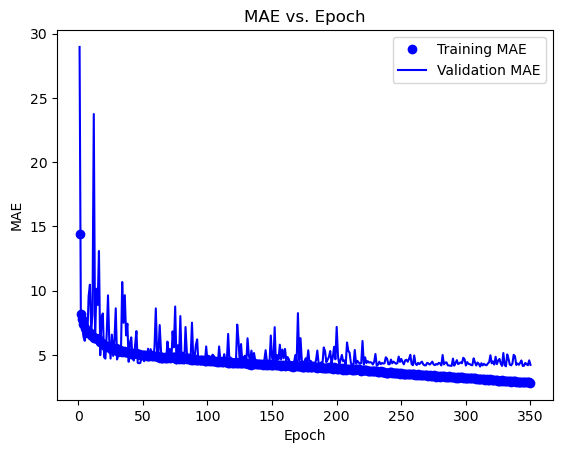

In [8]:
def make_model(): # Normal C1 Model
    model = get_model()
    model.compile(optimizer=Adam(learning_rate=0.001), loss=MeanAbsoluteError(), metrics=['mean_absolute_error'])

    csv_logger = CSVLogger('/mnt/md0/tempFolder/Allen/Models/RotateTranslateScale4.csv')

    checkpoint = ModelCheckpoint('/mnt/md0/tempFolder/Allen/Models/RotateTranslateScale4.keras', monitor='val_mean_absolute_error', verbose=1, save_best_only=True, mode='min')
    history = model.fit(X_train_augmented, y_train_duplicated, epochs=350, callbacks=[checkpoint, csv_logger], batch_size=14, validation_data=(X_val, y_val), verbose=1)

    train_mae = history.history['mean_absolute_error']
    val_mae = history.history['val_mean_absolute_error']
    epochs = range(1, len(train_mae) + 1)

    plt.figure()
    plt.plot(epochs, train_mae, 'bo', label='Training MAE')
    plt.plot(epochs, val_mae, 'b', label='Validation MAE')
    plt.title('MAE vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()


    return history

model = make_model()

In [6]:
rotatetranslatescalemodel = tf.keras.models.load_model('/mnt/md0/tempFolder/Allen/Models/RotateTranslateScale4.keras')
rotatetranslatescalepredictions = rotatetranslatescalemodel.predict(camimages)
rotatetranslatescalemae = mean_absolute_error(camcanage, rotatetranslatescalepredictions)
print("Rotate, translate, and scale test (done 4 times) MAE: ", rotatetranslatescalemae,  "\n")

2024-07-15 19:05:42.435402: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step
Rotate, translate, and scale test (done 4 times) MAE:  12.177804724111718 



In [8]:
# Saliency Map generation function with binary mask
def Normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))
def saliencyBinaryMap(model, X):
    saliencyMaps = []
    for idx, i in enumerate(X):
        img = i.reshape((1, *X[0].shape))
        img = img.reshape((*img.shape, 1))
        #print(np.shape(i), *X[0].shape, np.shape(img))
        img = tf.Variable(img, dtype=float)
        with tf.GradientTape() as tape:
            pred  = model(img, training=False)
            #print('prediction: ', pred)
            classSorted = np.argsort(pred.numpy().flatten())[::-1]
            #print('classSorted: ', classSorted)
            loss = pred[0][classSorted[0]]
            #print('loss: ', loss)
        grad = tape.gradient(loss, img)
        gradAbs = tf.math.abs(grad)
        gradMax = np.max(gradAbs, axis=4)[0]
        #print('grad shape: ', np.shape(grad))
# create binary mask using i, with 1 inside the brain and 0 outside
        binaryMask = np.where(i > 0, 1, 0)
        gradMax = gradMax * binaryMask
# only keep voxels in gradMax that are 1 in the binary mask
        saliencyMaps.append(Normalize(gradMax))
    return np.asarray(saliencyMaps)

In [ ]:
def SaliencyPicture():
    Model = tf.keras.models.load_model('/mnt/md0/tempFolder/Allen/Models/RotateTranslateScale4.keras')
    Saliency = saliencyBinaryMap(Model, camimages)

    saldir = '/mnt/md0/tempFolder/Allen/AugmentationSaliencies/'
    np.save(saldir + 'RotateTranslateScaleSaliency.npy', Saliency)
    avgsal = np.mean(Saliency, axis = 0)
    fig, ax = plt.subplots(1, 3, figsize=(10, 3))
    for axes in ax:
        axes.set_aspect('equal')
        axes.axis('off')

    im = ax[0].imshow(avgsal[64, :, :], vmin=0)
    #ax[0].set_title('Slice 16 (YZ plane)')
    ax[1].imshow(avgsal[:, 64, :], vmin=0)
    #ax[1].set_title('Slice 16 (XZ plane)')
    ax[2].imshow(avgsal[:, :, 64], vmin=0)
    #ax[2].set_title('Slice 16 (XY plane)')

    fig.colorbar(im, ax=ax, orientation='vertical', fraction=.1)

    #plt.savefig(f"saldir/scalesaliencyavg.png")

    plt.show()
SaliencyPicture()

In [6]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error
from skimage.metrics import hausdorff_distance
from skimage.metrics import normalized_mutual_information
from statistics import mean
from scipy import stats


def adjustIntensity(saliencyMap, rawImage):
    # returns images with intensity normalized between 0 and 1
    mnraw = np.min(np.min(np.min(rawImage, axis=0),axis=0),axis=0)
    mxraw = np.max(np.max(np.max(rawImage, axis=0),axis=0),axis=0)
    
    mnsal = np.min(np.min(np.min(saliencyMap, axis=0),axis=0),axis=0)
    mxsal = np.max(np.max(np.max(saliencyMap, axis=0),axis=0),axis=0)
    
    sal2 = (saliencyMap - mnsal)/(mxsal - mnsal)
    raw2 = (rawImage - mnraw)/(mxraw - mnraw)
    
    sal2 = np.where(sal2 > 0.2, 1, 0)
    raw2 = np.where(raw2 > 0.2, 1, 0)
    
    return sal2, raw2

def confidence_interval(data, confidence=0.95):
    # Calculate the mean and the standard error
    mean = np.mean(data)
    sem = stats.sem(data)
    # Calculate the confidence interval
    ci = sem * stats.t.ppf((1 + confidence) / 2., len(data)-1)
    return mean, mean-ci, mean+ci

def structSim3D(saliencyMap, rawImage):
    # returns mean structural similarity index
    sMap, rImage = adjustIntensity(saliencyMap, rawImage)
    dataRange = 1 - 0 # change if intensity is not adjusted
    ssi = ssim(sMap, rImage, data_range=dataRange)
    return ssi

def mse(saliencyMap, rawImage):
    # returns mean squared error
    saliencyMap, rawImage = adjustIntensity(saliencyMap, rawImage)
    return mean_squared_error(saliencyMap, rawImage)

# def hd(saliencyMap, rawImage):
#     # returns Hausdorff distance between coordinates of non-0 voxels
#     # change method to modified if needed
#     saliencyMap, rawImage = adjustIntensity(saliencyMap, rawImage)
#     return hausdorff_distance(saliencyMap, rawImage)

def nmi(saliencyMap, rawImage):
    # returns normalized mutual information. 
    # Higher NMI implies more similar input images.
    saliencyMap, rawImage = adjustIntensity(saliencyMap, rawImage)
    return normalized_mutual_information(saliencyMap, rawImage)

def dice_coefficient(saliencyMap, rawImage):
    saliencyMap, rawImage = adjustIntensity(saliencyMap, rawImage)
    return np.sum(saliencyMap[rawImage==1])*2.0 / (np.sum(saliencyMap) + np.sum(rawImage))

functions = [structSim3D, mse, nmi, dice_coefficient]

dir = '/mnt/md0/tempFolder/Allen/AugmentationSaliencies/'
models = ['NormalSaliencyAtlas','RotateTranslateScaleSaliency', 'Translate10Saliency']
# Initialize an empty dictionary to store the results of each function
function_results = {f: [] for f in functions}
normal_model_results = {}

for model in models:
    Saliency = np.load(os.path.join(dir, f'{model}.npy'))
    for i in range (651):
        saliencyFile = Saliency[i]
        brainMGZFile = camimages[i]
        for f in functions:
            result = f(saliencyFile, brainMGZFile)
            function_results[f].append(result)
    # After processing each model, calculate the mean and std of the results
    for f in functions:
        mean_result = np.mean(function_results[f])
        std_result = np.std(function_results[f])
        # If processing the 'NormalSaliencyAtlas' model, store the mean and std
        if model == 'NormalSaliencyAtlas':
            normal_model_results[f] = (mean_result, std_result)
            print(mean_result, std_result)
        else:
            # For other models, normalize the mean and std by the 'NormalSaliencyAtlas' results
            normalized_mean = mean_result / normal_model_results[f][0]
            normalized_std = std_result / normal_model_results[f][1]
            print(f'Result for {f.__name__} in {model}: {normalized_mean} ± {normalized_std}')
        function_results[f].clear()  # Clear the list for the next model

        
##Calculate confidence intervals, add dice coefficient

0.8157815414488846 0.0037583071931826914
0.10846361989432948 0.0026211216623212913
1.0001027125523139 9.1116542445452e-05
0.0019181572275622188 0.0010633903832810033
Result for structSim3D in RotateTranslateScaleSaliency: 0.9992541934578694 ± 1.0097703873983022
Result for mse in RotateTranslateScaleSaliency: 0.9993146317507599 ± 0.9849326884732861
Result for nmi in RotateTranslateScaleSaliency: 1.0007068699372375 ± 6.660742136971945
Result for dice_coefficient in RotateTranslateScaleSaliency: 3.410973387170408 ± 3.472213311036567
Result for structSim3D in Translate10Saliency: 1.000020757445105 ± 1.0111433082451597
Result for mse in Translate10Saliency: 0.9989413390716196 ± 0.9954243200184519
Result for nmi in Translate10Saliency: 1.0001511374491812 ± 2.3645728633405243
Result for dice_coefficient in Translate10Saliency: 1.2459044065668337 ± 1.3281011845359196


In [12]:
X_train_translate10 = augment.apply_augmentation(random_rotate, X_train, 10, SEED1)
np.save(dir + "X_train_translate10" + '.npy', X_train_translate10)

Calling function random_rotate
Rotating each image randomly between -10 degrees and +10 degrees
random_rotate executed successfully.


In [13]:
X_train_translate10andnormal = np.concatenate((X_train, X_train_translate10), axis=0) 
y_train_duplicated2 = np.concatenate((y_train, y_train), axis=0)

np.save(dir + "X_train_translate10andnormal" + '.npy', X_train_translate10andnormal)
np.save(dir + "y_train_duplicated2" + '.npy', y_train_duplicated2)

In [13]:
X_train_translate10andnormal = np.load(dir + 'X_train_translate10andnormal.npy')
y_train_duplicated2 = np.load(dir + 'y_train_duplicated2.npy')

Epoch 1/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - loss: 39.3741 - mean_absolute_error: 39.3741
Epoch 1: val_mean_absolute_error improved from inf to 18.37609, saving model to /mnt/md0/tempFolder/Allen/Models/Translate10.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 304s 745ms/step - loss: 39.3391 - mean_absolute_error: 39.3391 - val_loss: 18.3761 - val_mean_absolute_error: 18.3761
Epoch 2/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - loss: 11.6723 - mean_absolute_error: 11.6723
Epoch 2: val_mean_absolute_error improved from 18.37609 to 8.81836, saving model to /mnt/md0/tempFolder/Allen/Models/Translate10.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 296s 737ms/step - loss: 11.6699 - mean_absolute_error: 11.6699 - val_loss: 8.8184 - val_mean_absolute_error: 8.8184
Epoch 3/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - loss: 9.3090 - mean_absolute_error: 9.3090
Epoch 3: val_mean_absolute_error did not improve from 8.81836
401/401 ━━━━━━━━━━━━━━━━━━━━ 295s 735ms/step - loss: 9.3077 - mean_absolute_

Epoch 22/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - loss: 6.5490 - mean_absolute_error: 6.5490
Epoch 22: val_mean_absolute_error did not improve from 5.98791
401/401 ━━━━━━━━━━━━━━━━━━━━ 291s 727ms/step - loss: 6.5488 - mean_absolute_error: 6.5488 - val_loss: 9.6381 - val_mean_absolute_error: 9.6381
Epoch 23/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - loss: 6.3296 - mean_absolute_error: 6.3296
Epoch 23: val_mean_absolute_error did not improve from 5.98791
401/401 ━━━━━━━━━━━━━━━━━━━━ 290s 723ms/step - loss: 6.3297 - mean_absolute_error: 6.3297 - val_loss: 16.7217 - val_mean_absolute_error: 16.7217
Epoch 24/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - loss: 6.5012 - mean_absolute_error: 6.5012
Epoch 24: val_mean_absolute_error did not improve from 5.98791
401/401 ━━━━━━━━━━━━━━━━━━━━ 293s 731ms/step - loss: 6.5010 - mean_absolute_error: 6.5010 - val_loss: 8.6966 - val_mean_absolute_error: 8.6966
Epoch 25/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - loss: 6.3503 - mean

401/401 ━━━━━━━━━━━━━━━━━━━━ 292s 728ms/step - loss: 5.6755 - mean_absolute_error: 5.6755 - val_loss: 5.3997 - val_mean_absolute_error: 5.3997
Epoch 44/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - loss: 5.6778 - mean_absolute_error: 5.6778
Epoch 44: val_mean_absolute_error did not improve from 5.37460
401/401 ━━━━━━━━━━━━━━━━━━━━ 292s 729ms/step - loss: 5.6777 - mean_absolute_error: 5.6777 - val_loss: 6.2325 - val_mean_absolute_error: 6.2325
Epoch 45/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - loss: 5.5414 - mean_absolute_error: 5.5414
Epoch 45: val_mean_absolute_error did not improve from 5.37460
401/401 ━━━━━━━━━━━━━━━━━━━━ 285s 710ms/step - loss: 5.5417 - mean_absolute_error: 5.5417 - val_loss: 6.1394 - val_mean_absolute_error: 6.1394
Epoch 46/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - loss: 5.4987 - mean_absolute_error: 5.4987
Epoch 46: val_mean_absolute_error did not improve from 5.37460
401/401 ━━━━━━━━━━━━━━━━━━━━ 285s 711ms/step - loss: 5.4986 - mean_absolute_err

Epoch 87/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - loss: 5.2675 - mean_absolute_error: 5.2675
Epoch 87: val_mean_absolute_error did not improve from 4.99667
401/401 ━━━━━━━━━━━━━━━━━━━━ 287s 716ms/step - loss: 5.2673 - mean_absolute_error: 5.2673 - val_loss: 11.0431 - val_mean_absolute_error: 11.0431
Epoch 88/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - loss: 5.2471 - mean_absolute_error: 5.2471
Epoch 88: val_mean_absolute_error improved from 4.99667 to 4.91934, saving model to /mnt/md0/tempFolder/Allen/Models/Translate10.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 290s 723ms/step - loss: 5.2469 - mean_absolute_error: 5.2469 - val_loss: 4.9193 - val_mean_absolute_error: 4.9193
Epoch 89/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - loss: 5.1919 - mean_absolute_error: 5.1919
Epoch 89: val_mean_absolute_error did not improve from 4.91934
401/401 ━━━━━━━━━━━━━━━━━━━━ 287s 715ms/step - loss: 5.1918 - mean_absolute_error: 5.1918 - val_loss: 7.1563 - val_mean_absolute_error: 7.1563
Epoch

Epoch 109/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - loss: 5.0796 - mean_absolute_error: 5.0796
Epoch 109: val_mean_absolute_error did not improve from 4.91934
401/401 ━━━━━━━━━━━━━━━━━━━━ 290s 723ms/step - loss: 5.0796 - mean_absolute_error: 5.0796 - val_loss: 5.3053 - val_mean_absolute_error: 5.3053
Epoch 110/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - loss: 5.0907 - mean_absolute_error: 5.0907
Epoch 110: val_mean_absolute_error improved from 4.91934 to 4.83549, saving model to /mnt/md0/tempFolder/Allen/Models/Translate10.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 291s 726ms/step - loss: 5.0906 - mean_absolute_error: 5.0906 - val_loss: 4.8355 - val_mean_absolute_error: 4.8355
Epoch 111/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - loss: 5.1662 - mean_absolute_error: 5.1662
Epoch 111: val_mean_absolute_error did not improve from 4.83549
401/401 ━━━━━━━━━━━━━━━━━━━━ 289s 720ms/step - loss: 5.1661 - mean_absolute_error: 5.1661 - val_loss: 5.1617 - val_mean_absolute_error: 5.1617
E

...

401/401 ━━━━━━━━━━━━━━━━━━━━ 292s 727ms/step - loss: 4.5361 - mean_absolute_error: 4.5361 - val_loss: 5.0295 - val_mean_absolute_error: 5.0295
Epoch 196/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - loss: 4.9231 - mean_absolute_error: 4.9231
Epoch 196: val_mean_absolute_error did not improve from 4.74779
401/401 ━━━━━━━━━━━━━━━━━━━━ 290s 723ms/step - loss: 4.9230 - mean_absolute_error: 4.9230 - val_loss: 4.8752 - val_mean_absolute_error: 4.8752
Epoch 197/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - loss: 4.7565 - mean_absolute_error: 4.7565
Epoch 197: val_mean_absolute_error did not improve from 4.74779
401/401 ━━━━━━━━━━━━━━━━━━━━ 293s 730ms/step - loss: 4.7565 - mean_absolute_error: 4.7565 - val_loss: 5.3140 - val_mean_absolute_error: 5.3140
Epoch 198/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - loss: 4.8637 - mean_absolute_error: 4.8637
Epoch 198: val_mean_absolute_error did not improve from 4.74779
401/401 ━━━━━━━━━━━━━━━━━━━━ 284s 707ms/step - loss: 4.8636 - mean_absolu

Epoch 239/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - loss: 4.6400 - mean_absolute_error: 4.6400
Epoch 239: val_mean_absolute_error did not improve from 4.70426
401/401 ━━━━━━━━━━━━━━━━━━━━ 285s 710ms/step - loss: 4.6399 - mean_absolute_error: 4.6399 - val_loss: 4.9796 - val_mean_absolute_error: 4.9796
Epoch 240/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - loss: 4.6765 - mean_absolute_error: 4.6765
Epoch 240: val_mean_absolute_error did not improve from 4.70426
401/401 ━━━━━━━━━━━━━━━━━━━━ 279s 696ms/step - loss: 4.6764 - mean_absolute_error: 4.6764 - val_loss: 4.9346 - val_mean_absolute_error: 4.9346
Epoch 241/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - loss: 4.4700 - mean_absolute_error: 4.4700
Epoch 241: val_mean_absolute_error did not improve from 4.70426
401/401 ━━━━━━━━━━━━━━━━━━━━ 274s 684ms/step - loss: 4.4702 - mean_absolute_error: 4.4702 - val_loss: 4.8630 - val_mean_absolute_error: 4.8630
Epoch 242/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - loss: 4.6437 -

Epoch 282/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - loss: 4.5017 - mean_absolute_error: 4.5017
Epoch 282: val_mean_absolute_error improved from 4.65283 to 4.63135, saving model to /mnt/md0/tempFolder/Allen/Models/Translate10.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 276s 688ms/step - loss: 4.5017 - mean_absolute_error: 4.5017 - val_loss: 4.6314 - val_mean_absolute_error: 4.6314
Epoch 283/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - loss: 4.6164 - mean_absolute_error: 4.6164
Epoch 283: val_mean_absolute_error did not improve from 4.63135
401/401 ━━━━━━━━━━━━━━━━━━━━ 275s 686ms/step - loss: 4.6162 - mean_absolute_error: 4.6162 - val_loss: 4.8671 - val_mean_absolute_error: 4.8671
Epoch 284/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - loss: 4.4764 - mean_absolute_error: 4.4764
Epoch 284: val_mean_absolute_error did not improve from 4.63135
401/401 ━━━━━━━━━━━━━━━━━━━━ 274s 683ms/step - loss: 4.4763 - mean_absolute_error: 4.4763 - val_loss: 4.7200 - val_mean_absolute_error: 4.7200
E

Epoch 325/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - loss: 4.3720 - mean_absolute_error: 4.3720
Epoch 325: val_mean_absolute_error did not improve from 4.63004
401/401 ━━━━━━━━━━━━━━━━━━━━ 279s 697ms/step - loss: 4.3719 - mean_absolute_error: 4.3719 - val_loss: 5.1148 - val_mean_absolute_error: 5.1148
Epoch 326/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - loss: 4.5794 - mean_absolute_error: 4.5794
Epoch 326: val_mean_absolute_error did not improve from 4.63004
401/401 ━━━━━━━━━━━━━━━━━━━━ 271s 677ms/step - loss: 4.5793 - mean_absolute_error: 4.5793 - val_loss: 5.7114 - val_mean_absolute_error: 5.7114
Epoch 327/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - loss: 4.2930 - mean_absolute_error: 4.2930
Epoch 327: val_mean_absolute_error did not improve from 4.63004
401/401 ━━━━━━━━━━━━━━━━━━━━ 282s 702ms/step - loss: 4.2933 - mean_absolute_error: 4.2933 - val_loss: 4.6882 - val_mean_absolute_error: 4.6882
Epoch 328/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - loss: 4.2488 -

Epoch 347/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - loss: 4.3566 - mean_absolute_error: 4.3566
Epoch 347: val_mean_absolute_error did not improve from 4.63004
401/401 ━━━━━━━━━━━━━━━━━━━━ 275s 685ms/step - loss: 4.3564 - mean_absolute_error: 4.3564 - val_loss: 5.7591 - val_mean_absolute_error: 5.7591
Epoch 348/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - loss: 4.2334 - mean_absolute_error: 4.2334
Epoch 348: val_mean_absolute_error did not improve from 4.63004
401/401 ━━━━━━━━━━━━━━━━━━━━ 274s 683ms/step - loss: 4.2334 - mean_absolute_error: 4.2334 - val_loss: 5.6215 - val_mean_absolute_error: 5.6215
Epoch 349/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - loss: 4.4045 - mean_absolute_error: 4.4045
Epoch 349: val_mean_absolute_error did not improve from 4.63004
401/401 ━━━━━━━━━━━━━━━━━━━━ 276s 689ms/step - loss: 4.4047 - mean_absolute_error: 4.4047 - val_loss: 4.6339 - val_mean_absolute_error: 4.6339
Epoch 350/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - loss: 4.3848 -

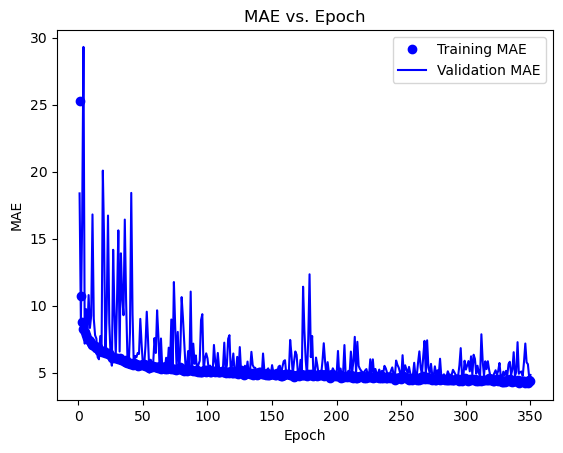

In [18]:
def make_model_translate10(): # Translate10
    model = get_model()
    model.compile(optimizer=Adam(learning_rate=0.001), loss=MeanAbsoluteError(), metrics=['mean_absolute_error'])

    csv_logger = CSVLogger('/mnt/md0/tempFolder/Allen/Models/Translate10.csv')

    checkpoint = ModelCheckpoint('/mnt/md0/tempFolder/Allen/Models/Translate10.keras', monitor='val_mean_absolute_error', verbose=1, save_best_only=True, mode='min')
    history = model.fit(X_train_translate10andnormal, y_train_duplicated2, epochs=350, callbacks=[checkpoint, csv_logger], batch_size=14, validation_data=(X_val, y_val), verbose=1)

    train_mae = history.history['mean_absolute_error']
    val_mae = history.history['val_mean_absolute_error']
    epochs = range(1, len(train_mae) + 1)

    plt.figure()
    plt.plot(epochs, train_mae, 'bo', label='Training MAE')
    plt.plot(epochs, val_mae, 'b', label='Validation MAE')
    plt.title('MAE vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()


    return history

model = make_model_translate10()

In [5]:
translate10model = tf.keras.models.load_model('/mnt/md0/tempFolder/Allen/Models/Translate10.keras')
translate10predictions = translate10model.predict(camimages)
translate10mae = mean_absolute_error(camcanage, translate10predictions)
print("Translate 10 MAE: ", translate10mae,  "\n")

21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 299ms/step
Translate 10 MAE:  13.412013555430049 



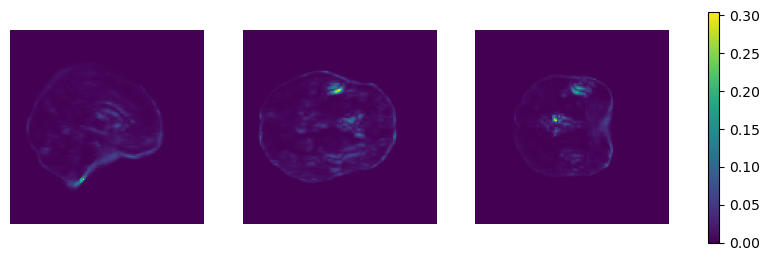

In [9]:
def SaliencyPicture_Translate10():
    Model = tf.keras.models.load_model('/mnt/md0/tempFolder/Allen/Models/Translate10.keras')
    Saliency = saliencyBinaryMap(Model, camimages)

    saldir = '/mnt/md0/tempFolder/Allen/AugmentationSaliencies/'
    np.save(saldir + 'Translate10Saliency.npy', Saliency)
    avgsal = np.mean(Saliency, axis = 0)
    fig, ax = plt.subplots(1, 3, figsize=(10, 3))
    for axes in ax:
        axes.set_aspect('equal')
        axes.axis('off')

    im = ax[0].imshow(avgsal[64, :, :], vmin=0)
    #ax[0].set_title('Slice 16 (YZ plane)')
    ax[1].imshow(avgsal[:, 64, :], vmin=0)
    #ax[1].set_title('Slice 16 (XZ plane)')
    ax[2].imshow(avgsal[:, :, 64], vmin=0)
    #ax[2].set_title('Slice 16 (XY plane)')

    fig.colorbar(im, ax=ax, orientation='vertical', fraction=.1)

    #plt.savefig(f"saldir/scalesaliencyavg.png")

    plt.show()
SaliencyPicture_Translate10()

In [6]:
X_train_translate5 = augment.apply_augmentation(random_translate, X_train, 5, SEED1)

Calling function random_translate
Translating each image randomly between (-5, -5, -5) voxels and (+5, +5, +5) voxels
Minimum coordinates across all axes prior to translation [30 33  2]
Maximum coordinates across all axes prior to translation [ 96 100  85]
Minimum coordinates across all axes after to translation [29.02400387 30.95655203 -1.72712201]
Maximum coordinates across all axes after to translation [95.02400387 97.95655203 81.27287799]
Minimum coordinates across all axes prior to translation [17  4  3]
Maximum coordinates across all axes prior to translation [113 119 117]
Minimum coordinates across all axes after to translation [12.55912004  1.58259646 -0.1996246 ]
Maximum coordinates across all axes after to translation [108.55912004 116.58259646 113.8003754 ]
Minimum coordinates across all axes prior to translation [24  3 12]
Maximum coordinates across all axes prior to translation [ 95  81 102]
Minimum coordinates across all axes after to translation [19.96333629 -1.23482741 

In [7]:
np.save(dir + "X_train_translate5" + '.npy', X_train_translate5)

In [11]:
X_train_translate5andnormal = np.concatenate((X_train, X_train_translate5), axis=0) 


np.save(dir + "X_train_translate5andnormal" + '.npy', X_train_translate5andnormal)

In [12]:
X_train_translate5andnormal = np.load(dir + "X_train_translate5andnormal" + '.npy')

2024-07-25 20:40:06.418012: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - loss: 37.7512 - mean_absolute_error: 37.7512
Epoch 1: val_mean_absolute_error improved from inf to 42.52095, saving model to /mnt/md0/tempFolder/Allen/Models/Translate5.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 282s 696ms/step - loss: 37.7164 - mean_absolute_error: 37.7164 - val_loss: 42.5209 - val_mean_absolute_error: 42.5209
Epoch 2/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - loss: 12.0023 - mean_absolute_error: 12.0023
Epoch 2: val_mean_absolute_error improved from 42.52095 to 20.00531, saving model to /mnt/md0/tempFolder/Allen/Models/Translate5.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 276s 688ms/step - loss: 12.0005 - mean_absolute_error: 12.0005 - val_loss: 20.0053 - val_mean_absolute_error: 20.0053
Epoch 3/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - loss: 10.1934 - mean_absolute_error: 10.1934
Epoch 3: val_mean_absolute_error improved from 20.00531 to 18.87286, saving model to /mnt/md0/tempFolder/Allen/Models/Translate5.keras


Epoch 22/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - loss: 6.8384 - mean_absolute_error: 6.8384
Epoch 22: val_mean_absolute_error did not improve from 8.33231
401/401 ━━━━━━━━━━━━━━━━━━━━ 277s 692ms/step - loss: 6.8383 - mean_absolute_error: 6.8383 - val_loss: 15.5989 - val_mean_absolute_error: 15.5989
Epoch 23/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - loss: 6.6920 - mean_absolute_error: 6.6920
Epoch 23: val_mean_absolute_error did not improve from 8.33231
401/401 ━━━━━━━━━━━━━━━━━━━━ 278s 694ms/step - loss: 6.6921 - mean_absolute_error: 6.6921 - val_loss: 30.9239 - val_mean_absolute_error: 30.9239
Epoch 24/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - loss: 6.6451 - mean_absolute_error: 6.6451
Epoch 24: val_mean_absolute_error did not improve from 8.33231
401/401 ━━━━━━━━━━━━━━━━━━━━ 278s 692ms/step - loss: 6.6454 - mean_absolute_error: 6.6454 - val_loss: 12.9657 - val_mean_absolute_error: 12.9657
Epoch 25/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - loss: 6.3893 - 

401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - loss: 5.8083 - mean_absolute_error: 5.8083
Epoch 43: val_mean_absolute_error did not improve from 5.45561
401/401 ━━━━━━━━━━━━━━━━━━━━ 280s 699ms/step - loss: 5.8085 - mean_absolute_error: 5.8085 - val_loss: 6.1439 - val_mean_absolute_error: 6.1439
Epoch 44/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - loss: 5.9412 - mean_absolute_error: 5.9412
Epoch 44: val_mean_absolute_error did not improve from 5.45561
401/401 ━━━━━━━━━━━━━━━━━━━━ 280s 699ms/step - loss: 5.9412 - mean_absolute_error: 5.9412 - val_loss: 12.0101 - val_mean_absolute_error: 12.0101
Epoch 45/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - loss: 5.9906 - mean_absolute_error: 5.9906
Epoch 45: val_mean_absolute_error improved from 5.45561 to 5.45063, saving model to /mnt/md0/tempFolder/Allen/Models/Translate5.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 278s 694ms/step - loss: 5.9902 - mean_absolute_error: 5.9902 - val_loss: 5.4506 - val_mean_absolute_error: 5.4506
Epoch 46/350
401/40

401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - loss: 5.6386 - mean_absolute_error: 5.6386
Epoch 64: val_mean_absolute_error did not improve from 5.06286
401/401 ━━━━━━━━━━━━━━━━━━━━ 268s 668ms/step - loss: 5.6386 - mean_absolute_error: 5.6386 - val_loss: 6.6003 - val_mean_absolute_error: 6.6003
Epoch 65/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - loss: 5.7325 - mean_absolute_error: 5.7325
Epoch 65: val_mean_absolute_error did not improve from 5.06286
401/401 ━━━━━━━━━━━━━━━━━━━━ 268s 669ms/step - loss: 5.7321 - mean_absolute_error: 5.7321 - val_loss: 15.5700 - val_mean_absolute_error: 15.5700
Epoch 66/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - loss: 5.6379 - mean_absolute_error: 5.6379
Epoch 66: val_mean_absolute_error did not improve from 5.06286
401/401 ━━━━━━━━━━━━━━━━━━━━ 268s 669ms/step - loss: 5.6379 - mean_absolute_error: 5.6379 - val_loss: 14.8956 - val_mean_absolute_error: 14.8956
Epoch 67/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - loss: 5.5025 - mean_absolute_e

...

Epoch 260/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - loss: 4.5633 - mean_absolute_error: 4.5633
Epoch 260: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 263s 655ms/step - loss: 4.5633 - mean_absolute_error: 4.5633 - val_loss: 6.7886 - val_mean_absolute_error: 6.7886
Epoch 261/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - loss: 4.6667 - mean_absolute_error: 4.6667
Epoch 261: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 263s 655ms/step - loss: 4.6666 - mean_absolute_error: 4.6666 - val_loss: 6.6632 - val_mean_absolute_error: 6.6632
Epoch 262/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - loss: 4.7347 - mean_absolute_error: 4.7347
Epoch 262: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 264s 659ms/step - loss: 4.7345 - mean_absolute_error: 4.7345 - val_loss: 7.8972 - val_mean_absolute_error: 7.8972
Epoch 263/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - loss: 4.7086 -

Epoch 282/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - loss: 4.6105 - mean_absolute_error: 4.6105
Epoch 282: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 264s 657ms/step - loss: 4.6105 - mean_absolute_error: 4.6105 - val_loss: 6.9699 - val_mean_absolute_error: 6.9699
Epoch 283/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - loss: 4.4683 - mean_absolute_error: 4.4683
Epoch 283: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 263s 655ms/step - loss: 4.4685 - mean_absolute_error: 4.4685 - val_loss: 4.9604 - val_mean_absolute_error: 4.9604
Epoch 284/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - loss: 4.5620 - mean_absolute_error: 4.5620
Epoch 284: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 265s 660ms/step - loss: 4.5621 - mean_absolute_error: 4.5621 - val_loss: 6.0821 - val_mean_absolute_error: 6.0821
Epoch 285/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - loss: 4.5086 -

Epoch 304/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - loss: 4.6916 - mean_absolute_error: 4.6916
Epoch 304: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 264s 659ms/step - loss: 4.6913 - mean_absolute_error: 4.6913 - val_loss: 8.1807 - val_mean_absolute_error: 8.1807
Epoch 305/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - loss: 4.4614 - mean_absolute_error: 4.4614
Epoch 305: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 263s 656ms/step - loss: 4.4616 - mean_absolute_error: 4.4616 - val_loss: 5.4204 - val_mean_absolute_error: 5.4204
Epoch 306/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - loss: 4.5590 - mean_absolute_error: 4.5590
Epoch 306: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 263s 656ms/step - loss: 4.5591 - mean_absolute_error: 4.5591 - val_loss: 10.6608 - val_mean_absolute_error: 10.6608
Epoch 307/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - loss: 4.5188

Epoch 326/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - loss: 4.5113 - mean_absolute_error: 4.5113
Epoch 326: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 264s 659ms/step - loss: 4.5111 - mean_absolute_error: 4.5111 - val_loss: 5.6060 - val_mean_absolute_error: 5.6060
Epoch 327/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - loss: 4.5453 - mean_absolute_error: 4.5453
Epoch 327: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 264s 659ms/step - loss: 4.5453 - mean_absolute_error: 4.5453 - val_loss: 7.2258 - val_mean_absolute_error: 7.2258
Epoch 328/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - loss: 4.7866 - mean_absolute_error: 4.7866
Epoch 328: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 264s 659ms/step - loss: 4.7862 - mean_absolute_error: 4.7862 - val_loss: 9.3274 - val_mean_absolute_error: 9.3274
Epoch 329/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - loss: 4.2567 -

Epoch 348/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - loss: 4.5520 - mean_absolute_error: 4.5520
Epoch 348: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 264s 658ms/step - loss: 4.5518 - mean_absolute_error: 4.5518 - val_loss: 19.4205 - val_mean_absolute_error: 19.4205
Epoch 349/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - loss: 4.4242 - mean_absolute_error: 4.4242
Epoch 349: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 264s 659ms/step - loss: 4.4241 - mean_absolute_error: 4.4241 - val_loss: 4.8803 - val_mean_absolute_error: 4.8803
Epoch 350/350
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - loss: 4.2345 - mean_absolute_error: 4.2345
Epoch 350: val_mean_absolute_error did not improve from 4.67238
401/401 ━━━━━━━━━━━━━━━━━━━━ 264s 658ms/step - loss: 4.2345 - mean_absolute_error: 4.2345 - val_loss: 4.8899 - val_mean_absolute_error: 4.8899


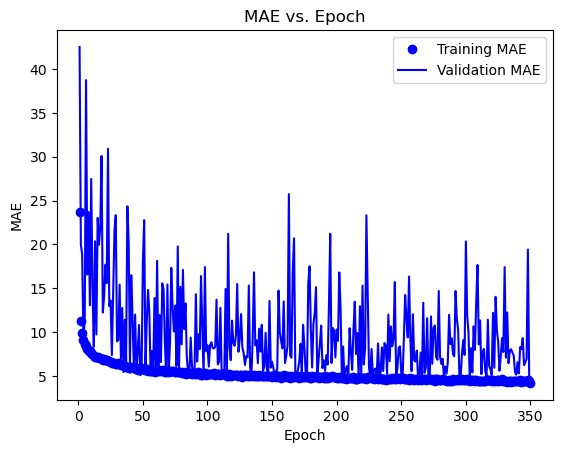

In [16]:
def make_translate5model(): # Translate5 Model
    model = get_model()
    model.compile(optimizer=Adam(learning_rate=0.001), loss=MeanAbsoluteError(), metrics=['mean_absolute_error'])

    csv_logger = CSVLogger('/mnt/md0/tempFolder/Allen/Models/Translate5.csv')

    checkpoint = ModelCheckpoint('/mnt/md0/tempFolder/Allen/Models/Translate5.keras', monitor='val_mean_absolute_error', verbose=1, save_best_only=True, mode='min')
    history = model.fit(X_train_translate5andnormal, y_train_duplicated2, epochs=350, callbacks=[checkpoint, csv_logger], batch_size=14, validation_data=(X_val, y_val), verbose=1)

    train_mae = history.history['mean_absolute_error']
    val_mae = history.history['val_mean_absolute_error']
    epochs = range(1, len(train_mae) + 1)

    plt.figure()
    plt.plot(epochs, train_mae, 'bo', label='Training MAE')
    plt.plot(epochs, val_mae, 'b', label='Validation MAE')
    plt.title('MAE vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()


    return history

model = make_translate5model()

In [17]:
translate5model = tf.keras.models.load_model('/mnt/md0/tempFolder/Allen/Models/Translate5.keras')
translate5predictions = translate5model.predict(camimages)
translate5mae = mean_absolute_error(camcanage, translate5predictions)
print("Translate 5 MAE: ", translate5mae,  "\n")

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 290ms/step
Translate 5 MAE:  12.716970803631433 

